# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from IPython.display import Markdown, display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [3]:
df = pd.read_csv(r"C:\Users\Rafael\Downloads\Cursos\Ebac\Curso de Ciencia de Dados\16 - Regressão\ALUGUEL_MOD12.csv", delimiter=';')
df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [4]:
print(df.dtypes)
print('\n')

print("--- Total de nulos por coluna ---")
print(df.isnull().sum())

print("\n--- Porcentagem de nulos (%) ---")
print((df.isnull().sum() / len(df)) * 100)

resumo_nulos = pd.DataFrame(
    {"Qtd_Nulos": df.isnull().sum(), "Porcentagem_%": (df.isnull().sum() / len(df)) * 100}
)
print("\n--- Tabela Resumo ---")
print(resumo_nulos)

Valor_Aluguel       int64
Valor_Condominio    int64
Metragem            int64
N_Quartos           int64
N_banheiros         int64
N_Suites            int64
N_Vagas             int64
dtype: object


--- Total de nulos por coluna ---
Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

--- Porcentagem de nulos (%) ---
Valor_Aluguel       0.0
Valor_Condominio    0.0
Metragem            0.0
N_Quartos           0.0
N_banheiros         0.0
N_Suites            0.0
N_Vagas             0.0
dtype: float64

--- Tabela Resumo ---
                  Qtd_Nulos  Porcentagem_%
Valor_Aluguel             0            0.0
Valor_Condominio          0            0.0
Metragem                  0            0.0
N_Quartos                 0            0.0
N_banheiros               0            0.0
N_Suites                  0            0.0
N_Vagas                   0            0.0


# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [5]:
print(df.describe())

fig = px.box(
    df,
    y=df.select_dtypes(include=["number"]).columns,
    title="Box Plot Interativo - Todas as Colunas Numéricas",
    points="outliers",
)
fig.show()

       Valor_Aluguel  Valor_Condominio     Metragem    N_Quartos  N_banheiros  \
count    7203.000000       7203.000000  7203.000000  7203.000000  7203.000000   
mean     2966.596140        811.538109    88.506178     2.300153     2.095932   
std      2948.720385        796.564846    61.567505     0.826615     0.983812   
min       480.000000          0.000000    30.000000     1.000000     1.000000   
25%      1350.000000        395.000000    52.000000     2.000000     2.000000   
50%      2000.000000        592.000000    67.000000     2.000000     2.000000   
75%      3200.000000        980.000000   100.000000     3.000000     2.000000   
max     25000.000000       9500.000000   880.000000    10.000000     8.000000   

          N_Suites     N_Vagas  
count  7203.000000  7203.00000  
mean      1.016660     1.44176  
std       0.874204     0.86993  
min       0.000000     0.00000  
25%       1.000000     1.00000  
50%       1.000000     1.00000  
75%       1.000000     2.00000  
max   

In [6]:
limite_superior_aluguel = df["Valor_Aluguel"].quantile(0.99)
df["Valor_Aluguel"] = np.where(
    df["Valor_Aluguel"] > limite_superior_aluguel,
    limite_superior_aluguel,
    df["Valor_Aluguel"],
)

q_condo = df["Valor_Condominio"].quantile(0.99)
df = df[df["Valor_Condominio"] <= q_condo]

q_metragem = df["Metragem"].quantile(0.99)
df = df[df["Metragem"] <= q_metragem]

q_quartos = df["N_Quartos"].quantile(0.99)
q_banheiros = df["N_banheiros"].quantile(0.99)
q_suites = df["N_Suites"].quantile(0.99)
q_vagas = df["N_Vagas"].quantile(0.99)

df = df[
    (df["N_Quartos"] <= q_quartos)
    & (df["N_banheiros"] <= q_banheiros)
    & (df["N_Suites"] <= q_suites)
    & (df["N_Vagas"] <= q_vagas)
]

In [7]:
print(df.describe())

fig = px.box(
    df,
    y=df.select_dtypes(include=["number"]).columns,
    title="Box Plot Interativo - Todas as Colunas Numéricas",
    points="outliers",
)
fig.show()

       Valor_Aluguel  Valor_Condominio     Metragem    N_Quartos  N_banheiros  \
count    7016.000000       7016.000000  7016.000000  7016.000000  7016.000000   
mean     2733.208951        741.223347    82.414196     2.258552     2.029932   
std      2380.066205        617.741058    46.469516     0.785741     0.882854   
min       480.000000          0.000000    30.000000     1.000000     1.000000   
25%      1309.750000        390.000000    51.000000     2.000000     2.000000   
50%      1900.000000        580.000000    65.000000     2.000000     2.000000   
75%      3000.000000        917.250000    95.000000     3.000000     2.000000   
max     16000.000000       4000.000000   280.000000     4.000000     5.000000   

          N_Suites      N_Vagas  
count  7016.000000  7016.000000  
mean      0.957526     1.377993  
std       0.788852     0.754890  
min       0.000000     0.000000  
25%       1.000000     1.000000  
50%       1.000000     1.000000  
75%       1.000000     2.000000 

In [8]:
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=(
        "Metragem vs Aluguel",
        "Aluguel por Quartos",
        "Matriz de Correlação",
    ),
)

scatter = px.scatter(df, x="Metragem", y="Valor_Aluguel")
for trace in scatter.data:
    fig.add_trace(trace, row=1, col=1)

box = px.box(df, x="N_Quartos", y="Valor_Aluguel", color="N_Quartos")
for trace in box.data:
    fig.add_trace(trace, row=1, col=2)
    
matriz_corr = df.corr(numeric_only=True)
heatmap = go.Heatmap(
    z=matriz_corr.values,
    x=matriz_corr.columns,
    y=matriz_corr.index,
    colorscale="Blues",
    text=np.round(matriz_corr.values, 2),
    texttemplate="%{text}",
)
fig.add_trace(heatmap, row=1, col=3)

fig.update_layout(
    title_text=" Painel Bivariado de Análise de Imóveis",
    height=500,
    showlegend=False,
)

fig.update_xaxes(title_text="Metragem (m²)", row=1, col=1)
fig.update_yaxes(title_text="Valor Aluguel (R$)", row=1, col=1)

fig.update_xaxes(title_text="Nº de Quartos", row=1, col=2)
fig.update_yaxes(title_text="Valor Aluguel (R$)", row=1, col=2)

fig.show()

print("--- Métricas da Análise Bivariada ---")
print(
    f"Correlação de Pearson (Metragem x Aluguel): {df['Metragem'].corr(df['Valor_Aluguel']):.2f}\n"
)
print("Resumo do Aluguel agrupado por N_Quartos:")
print(df.groupby("N_Quartos")["Valor_Aluguel"].agg(["median", "mean", "std"]))

--- Métricas da Análise Bivariada ---
Correlação de Pearson (Metragem x Aluguel): 0.71

Resumo do Aluguel agrupado por N_Quartos:
           median         mean          std
N_Quartos                                  
1          1900.0  2317.171179  1545.969662
2          1500.0  1983.868712  1579.468246
3          2500.0  3457.623951  2696.055703
4          5500.0  6410.971264  3604.494547


In [9]:
# Insight dos Gráficos:
# Embora os gráficos apresentem pontos plotados fora dos limites superiores (fences do Boxplot)
# e linhas horizontais no topo das distribuições, isso decorre da estratégia de tratamento adotada
# (Capping via percentil) e não da ausência de tratamento. A única alternativa para eliminar completamente
# a presença visual desses pontos nos gráficos seria a exclusão total dos registros. Contudo, o descarte
# sumário desses dados acarretaria perda de informação relevante, distorcendo métricas de mercado e introduzindo
# viés de seleção na amostra. Optou-se por manter os dados no limite superior estipulado para preservar o volume
# da base e refletir o comportamento real de imóveis de padrão superior, garantindo uma modelagem mais robusta
# e representativa sem manipulação indevida dos resultados.

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




In [10]:
matriz_corr = df.corr(numeric_only=True)
fig_corr = px.imshow(
    matriz_corr,
    text_auto=".2f",
    color_continuous_scale="Greens",
    zmin=-1,
    zmax=1,
    title="Matriz de Correlação das Variáveis Numéricas",
    labels=dict(color="Correlação"),
    aspect="auto",
)

fig_corr.update_layout(
    title_x=0.5,
    xaxis_title="",
    yaxis_title="",
    width=700,
    height=550,
)

fig_corr.show()
sol = (
    matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
sol.columns = ["Variável 1", "Variável 2", "Correlação"]

correlacoes_fortes = sol[sol["Correlação"].abs() >= 0.60].sort_values(
    by="Correlação", ascending=False
)
texto_md = "### Principais Correlações Encontradas (Extraídas Dinamicamente)\n\n"

for _, row in correlacoes_fortes.iterrows():
    v1 = row["Variável 1"]
    v2 = row["Variável 2"]
    val = row["Correlação"]

    if val >= 0.90:
        classificacao = "Muito forte / Quase perfeita"
    elif val >= 0.70:
        classificacao = "Forte"
    else:
        classificacao = "Moderada-alta"

    texto_md += f"* **`{v1}` vs. `{v2}`**: **{val:.2f}** ({classificacao})\n"

display(Markdown(texto_md))

### Principais Correlações Encontradas (Extraídas Dinamicamente)

* **`N_banheiros` vs. `N_Suites`**: **0.91** (Muito forte / Quase perfeita)
* **`Valor_Condominio` vs. `Metragem`**: **0.77** (Forte)
* **`Metragem` vs. `N_Vagas`**: **0.71** (Forte)
* **`Valor_Aluguel` vs. `Metragem`**: **0.71** (Forte)
* **`Metragem` vs. `N_Quartos`**: **0.68** (Moderada-alta)
* **`Valor_Aluguel` vs. `Valor_Condominio`**: **0.67** (Moderada-alta)
* **`Metragem` vs. `N_banheiros`**: **0.67** (Moderada-alta)
* **`N_Suites` vs. `N_Vagas`**: **0.66** (Moderada-alta)
* **`Metragem` vs. `N_Suites`**: **0.66** (Moderada-alta)
* **`N_banheiros` vs. `N_Vagas`**: **0.66** (Moderada-alta)
* **`Valor_Condominio` vs. `N_Vagas`**: **0.65** (Moderada-alta)



B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [11]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [12]:
X = df.drop(columns=["Valor_Aluguel"])
y = df["Valor_Aluguel"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(" Divisão dos Dados Concluída com Sucesso:")
print(f"• Treino (X_train): {X_train.shape[0]} linhas | {X_train.shape[1]} colunas")
print(f"• Teste  (X_test) : {X_test.shape[0]} linhas | {X_test.shape[1]} colunas")
print(f"• Alvo Treino (y_train): {y_train.shape[0]} registros")
print(f"• Alvo Teste  (y_test) : {y_test.shape[0]} registros")

 Divisão dos Dados Concluída com Sucesso:
• Treino (X_train): 5612 linhas | 6 colunas
• Teste  (X_test) : 1404 linhas | 6 colunas
• Alvo Treino (y_train): 5612 registros
• Alvo Teste  (y_test) : 1404 registros


# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [13]:
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [14]:
X_train_simples = X_train[["Metragem"]]
X_test_simples = X_test[["Metragem"]]

modelo_simples = LinearRegression()
modelo_simples.fit(X_train_simples, y_train)

y_pred_train = modelo_simples.predict(X_train_simples)
y_pred_test = modelo_simples.predict(X_test_simples)

coef_angular = modelo_simples.coef_[0] 
intercepto = modelo_simples.intercept_  

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(" Equação da Regressão Linear Simples:")
print(
    f"   Valor_Aluguel = {coef_angular:.2f} * Metragem + ({intercepto:.2f})\n"
)

print(" Métricas de Desempenho:")
print(f"• R² (Treino): {r2_train:.4f}")
print(f"• R² (Teste) : {r2_test:.4f}")
print(f"• MAE (Erro Médio Absoluto no Teste) : R$ {mae_test:.2f}")
print(f"• RMSE (Raiz do Erro Quadrático Médio): R$ {rmse_test:.2f}")

 Equação da Regressão Linear Simples:
   Valor_Aluguel = 36.00 * Metragem + (-235.31)

 Métricas de Desempenho:
• R² (Treino): 0.4991
• R² (Teste) : 0.5179
• MAE (Erro Médio Absoluto no Teste) : R$ 1059.40
• RMSE (Raiz do Erro Quadrático Médio): R$ 1718.49


B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [15]:
coef_angular = modelo_simples.coef_[0]
intercepto = modelo_simples.intercept_

sinal_intercepto = "+" if intercepto >= 0 else "-"
equacao_extensa = (
    f"Valor_Aluguel = ({coef_angular:.4f} × Metragem) {sinal_intercepto} {abs(intercepto):.4f}"
)

print("=" * 60)
print("EQUAÇÃO EXTENSA DA RETA DA REGRESSÃO LINEAR SIMPLES:")
print(f" {equacao_extensa}")
print("=" * 60)
print(f"• Coeficiente Angular (a / Inclinação): {coef_angular:.4f}")
print(f"• Intercepto (b / Ponto de Corte no Eixo Y): {intercepto:.4f}\n")

x_range = np.linspace(X_train_simples["Metragem"].min(), X_train_simples["Metragem"].max(), 100)
y_range = modelo_simples.predict(pd.DataFrame({"Metragem": x_range}))
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=X_train_simples["Metragem"],
        y=y_train,
        mode="markers",
        name="Dados de Treino (Reais)",
        marker=dict(color="mediumseagreen", opacity=0.5, size=6),
    )
)
fig.add_trace(
    go.Scatter(
        x=x_range,
        y=y_range,
        mode="lines",
        name="Reta da Regressão Linear",
        line=dict(color="darkgreen", width=3),
    )
)
fig.add_trace(
    go.Scatter(
        x=[0],
        y=[intercepto],
        mode="markers+text",
        name="Intercepto (b)",
        marker=dict(color="red", size=12, symbol="diamond"),
        text=[f"  Intercepto: R$ {intercepto:.2f}"],
        textposition="top right",
    )
)
fig.update_layout(
    title="Reta de Regressão Linear Simples: Metragem vs. Valor_Aluguel",
    xaxis_title="Metragem (m²)",
    yaxis_title="Valor do Aluguel (R$)",
    legend=dict(x=0.01, y=0.99),
    width=800,
    height=550,
    annotations=[
        dict(
            x=0.5,
            y=1.05,
            xref="paper",
            yref="paper",
            text=f"<b>Equação:</b> {equacao_extensa}",
            showarrow=False,
            font=dict(size=13, color="black"),
            bgcolor="#E8F5E9",
            bordercolor="darkgreen",
            borderwidth=1,
        )
    ],
)

fig.show()

EQUAÇÃO EXTENSA DA RETA DA REGRESSÃO LINEAR SIMPLES:
 Valor_Aluguel = (36.0017 × Metragem) - 235.3089
• Coeficiente Angular (a / Inclinação): 36.0017
• Intercepto (b / Ponto de Corte no Eixo Y): -235.3089



Nossa equação seria:  

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [16]:
y_pred_train = modelo_simples.predict(X_train_simples)
r2_train = r2_score(y_train, y_pred_train)
print(f"R² (Treinamento): {r2_train:.4f} ou {r2_train * 100:.2f}%")

R² (Treinamento): 0.4991 ou 49.91%


In [17]:
# Insight da Equação da Reta:
# O R2 de 49,91% obtido no treino é um resultado extremamente positivo. No mercado imobiliário, onde 
# os preços sofrem influência de diversos fatores, constatar que o tamanho do imóvel sozinho responde por
# metade da precificação do aluguel confirma a Metragem como o principal direcionador de valor da base.

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

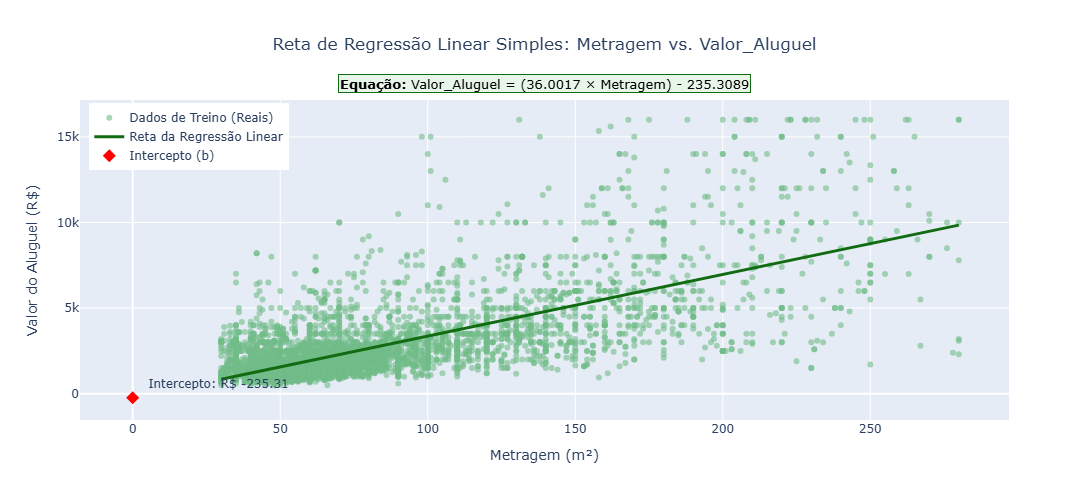

In [18]:
coef_angular = modelo_simples.coef_[0]
intercepto = modelo_simples.intercept_
x_linha = np.linspace(
    X_train["Metragem"].min(), X_train["Metragem"].max(), 100
)
y_linha = modelo_simples.predict(pd.DataFrame({"Metragem": x_linha}))
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=X_train["Metragem"],
        y=y_train,
        mode="markers",
        name="Dados de Treino (Reais)",
        marker=dict(color="#71bc88", opacity=0.6, size=6),
    )
)
fig.add_trace(
    go.Scatter(
        x=x_linha,
        y=y_linha,
        mode="lines",
        name="Reta da Regressão Linear",
        line=dict(color="#116b11", width=3),
    )
)
fig.add_trace(
    go.Scatter(
        x=[0],
        y=[intercepto],
        mode="markers+text",
        name="Intercepto (b)",
        marker=dict(color="red", size=10, symbol="diamond"),
        text=[f"  Intercepto: R$ {intercepto:.2f}"],
        textposition="top right",
    )
)
fig.update_layout(
    title="Reta de Regressão Linear Simples: Metragem vs. Valor_Aluguel",
    title_x=0.5,
    xaxis_title="Metragem (m²)",
    yaxis_title="Valor do Aluguel (R$)",
    width=850,
    height=500,
    legend=dict(x=0.01, y=0.99),
    annotations=[
        dict(
            x=0.5,
            y=1.08,
            xref="paper",
            yref="paper",
            text=f"<b>Equação:</b> Valor_Aluguel = ({coef_angular:.4f} × Metragem) - {abs(intercepto):.4f}",
            showarrow=False,
            font=dict(size=13, color="black"),
            bgcolor="#E8F5E9",
            bordercolor="#116b11",
            borderwidth=1,
        )
    ],
)
fig.show()

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [19]:
X_test = X_test[['Metragem']]  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo)

In [20]:
X_test_simples = X_test[["Metragem"]]

# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = modelo_simples.predict(X_test_simples)

# Avaliando o desempenho do modelo usando métricas como o R²
r2_teste = modelo_simples.score(X_test_simples, y_test)

print(f"Coeficiente de Determinação (R²) nos Dados de Teste: {r2_teste:.4f} ou {r2_teste * 100:.2f}%")

Coeficiente de Determinação (R²) nos Dados de Teste: 0.5179 ou 51.79%


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

#A validação do modelo na base de teste resultou em um Coeficiente de Determinação (R) de 51,79%, superando levemente os 49,91% obtidos no treinamento. Essa consistência entre treino e teste evidencia a ausência de overfitting e confirma a capacidade do modelo de generalizar previsões para novos imóveis. O resultado ratifica a Metragem como o principal driver isolado de preço do aluguel, explicando mais de metade de sua variância.  


# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [23]:
colunas_para_ajustar = [
    "Metragem",
    "N_Quartos",
    "N_Suites",
    "N_Vagas",
    "N_banheiros",
    "Valor_Condominio",
]
for col in colunas_para_ajustar:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Valor_Aluguel"] + colunas_para_ajustar)

X = df.drop(columns=["Valor_Aluguel"])
y = df["Valor_Aluguel"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(" Base dividida com sucesso para Regressão Múltipla:")
print(
    f"• X_train: {X_train.shape[0]} linhas x {X_train.shape[1]} colunas (Variáveis: {list(X_train.columns)})"
)
print(f"• X_test : {X_test.shape[0]} linhas x {X_test.shape[1]} colunas")
print(f"• y_train: {y_train.shape[0]} registros")
print(f"• y_test : {y_test.shape[0]} registros")

 Base dividida com sucesso para Regressão Múltipla:
• X_train: 5612 linhas x 6 colunas (Variáveis: ['Valor_Condominio', 'Metragem', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas'])
• X_test : 1404 linhas x 6 colunas
• y_train: 5612 registros
• y_test : 1404 registros


B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [24]:
X_train_multi = X_train.select_dtypes(include=[np.number])

modelo_multiplo = LinearRegression()

modelo_multiplo.fit(X_train_multi, y_train)

print("=" * 60)
print(" MODELO TREINADO COM SUCESSO (Apenas Base de Treino)")
print("=" * 60)
print(f"Intercepto (b) = R$ {modelo_multiplo.intercept_:.2f}\n")

df_coeficientes = pd.DataFrame(
    {
        "Variável Explicativa": X_train_multi.columns,
        "Coeficiente (R$)": modelo_multiplo.coef_,
    }
).sort_values(by="Coeficiente (R$)", ascending=False)

print("Coeficientes Aprendidos no Treino:")
print(df_coeficientes.to_string(index=False))

 MODELO TREINADO COM SUCESSO (Apenas Base de Treino)
Intercepto (b) = R$ 562.86

Coeficientes Aprendidos no Treino:
Variável Explicativa  Coeficiente (R$)
            N_Suites        481.225387
             N_Vagas        325.044671
         N_banheiros         62.276958
            Metragem         25.539621
    Valor_Condominio          0.873231
           N_Quartos       -715.611148


C) Traga o valor do R quadrado e avalie o valor encontrado.

In [25]:
r2_treino_multi = modelo_multiplo.score(X_train_multi, y_train)
print(f"Coeficiente de Determinação (R²) no Treinamento: {r2_treino_multi:.4f} ou {r2_treino_multi * 100:.2f}%")

Coeficiente de Determinação (R²) no Treinamento: 0.5890 ou 58.90%


D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [26]:
X_test_multi = X_test[X_train_multi.columns]

previsoes_teste_multi = modelo_multiplo.predict(X_test_multi)

r2_teste_multi = modelo_multiplo.score(X_test_multi, y_test)

print("=" * 60)
print(" AVALIAÇÃO DA REGRESSÃO MULTIPLA NA BASE DE TESTE")
print("=" * 60)
print(f"• R² (Treinamento) : {r2_treino_multi:.4f} ou {r2_treino_multi * 100:.2f}%")
print(f"• R² (Teste)       : {r2_teste_multi:.4f} ou {r2_teste_multi * 100:.2f}%")
print("=" * 60)

 AVALIAÇÃO DA REGRESSÃO MULTIPLA NA BASE DE TESTE
• R² (Treinamento) : 0.5890 ou 58.90%
• R² (Teste)       : 0.5942 ou 59.42%


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

In [ ]:
# A transição para a Regressão Linear Múltipla elevou o R2 na base de teste para 59,42% (frente aos 51,79% da regressão simples).
# A estreita alinhamento entre o R2 de treino (58,90%) e o de teste (59,42%) confirma a robustez e a excelente capacidade de generalização
# do modelo para novos dados de mercado. 

<!-- A transição para a Regressão Linear Múltipla elevou o R2 na base de teste para 59,42% (frente aos 51,79% da regressão simples). A estreita alinhamento entre o R2 de treino (58,90%) e o de teste (59,42%) confirma a robustez e a excelente capacidade de generalização do modelo para novos dados de mercado. -->